# Ejercicio 7

Utilice el dataset `estacion_meteorologica.csv`:

1. Calcule y grafique las matrices de correlación y covariancia.

2. Identifique las variables más correlacionadas y grafíquelas unas vs. la otra en un gráfico de dispersión. Luego grafique cada una a lo largo del tiempo (para todas las fechas).

3. Identifique las variables menos correlacionadas y grafíquelas unas vs. la otra en un gráfico de dispersión. Luego grafique cada una a lo largo del tiempo (para todas las fechas).

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Limpieza del df

In [43]:
df = pd.read_csv('../datasets/estacion_meteorologica.csv', sep=';')
df


,No,Date,Time,ColdJunc0,PowerVolt,PowerKind,WS(ave),WD(ave),WS(max),WD(most),WS(inst_m),WD(inst_m),Max_time,Solar_rad,TEMP,Humidity,Rainfall,Bar_press.,Soil_temp
0,92793,1/10/2021,0:00:00,"22,6",13,2,"0,4",19,"0,9",NE,"1,9",43,23:50:41,0,"22,5","82,39",0,1000,0
1,92794,1/10/2021,0:10:00,"22,5",13,2,1,131,1,ESE,"4,3",161,0:04:57,0,"22,3","84,09",0,1000,0
2,92795,1/10/2021,0:20:00,"22,5",13,2,"0,8",166,1,ESE,"3,7",145,0:13:00,0,"22,7","81,99",0,1000,0
3,92796,1/10/2021,0:30:00,"22,5",13,2,"0,7",205,"0,8",WSW,"3,1",160,0:25:55,0,"22,2","84,29",0,1000,0
4,92797,1/10/2021,0:40:00,"22,5","12,9",2,"0,6",134,"0,7",E,"4,3",121,0:35:35,0,"21,8","87,9",0,"999,7",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4459,97252,31/10/2021,23:10:00,"23,2",13,2,"1,3",232,"1,8",WSW,"6,7",240,23:09:17,0,"22,7","88,7",0,"1002,7",0
4460,97253,31/10/2021,23:20:00,"23,1",13,2,1,179,"1,3",NNE,"4,3",224,23:11:34,0,"22,7","88,8",0,"1002,7",0
4461,97254,31/10/2021,23:30:00,"23,1",13,2,"1,2",7,"1,5",NNE,"4,9",353,23:26:17,0,"22,9","88,8",0,"1003,1",0
4462,97255,31/10/2021,23:40:00,"23,1",13,2,"0,4",356,"1,2",NW,"3,1",121,23:33:21,0,"22,8","88,4",0,"1003,1",0


In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4464 entries, 0 to 4463
Data columns (total 19 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   No          4464 non-null   int64
 1   Date        4464 non-null   str  
 2   Time        4464 non-null   str  
 3   ColdJunc0   4464 non-null   str  
 4   PowerVolt   4464 non-null   str  
 5   PowerKind   4464 non-null   int64
 6   WS(ave)     4464 non-null   str  
 7   WD(ave)     4464 non-null   int64
 8   WS(max)     4464 non-null   str  
 9   WD(most)    4464 non-null   str  
 10  WS(inst_m)  4464 non-null   str  
 11  WD(inst_m)  4464 non-null   int64
 12  Max_time    4464 non-null   str  
 13  Solar_rad   4464 non-null   str  
 14  TEMP        4464 non-null   str  
 15  Humidity    4464 non-null   str  
 16  Rainfall    4464 non-null   str  
 17  Bar_press.  4464 non-null   str  
 18  Soil_temp   4464 non-null   str  
dtypes: int64(4), str(15)
memory usage: 662.8 KB


In [52]:
# Cambiamos la coma por un punto en las columnas numéricas

cols_numericas = ['ColdJunc0', 'PowerVolt', 'WS(ave)', 'WS(max)', 'WS(inst_m)',
                    'Solar_rad', 'TEMP', 'Humidity', 'Rainfall', 'Bar_press.', 'Soil_temp'
                    ]

for col in cols_numericas:
    df[col] = df[col].astype(str).str.replace(',', '.').astype(float)

In [46]:
# Creamos una variable que representa la fecha completa

df['fecha'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)

In [47]:
# La variable 'PowerKind' asume un solo valor

df['PowerKind'].value_counts()

PowerKind
2    4464
Name: count, dtype: int64

In [48]:
# Borramos variables que consideramos innecesarias

df = df.drop(columns=['No', 'Date', 'Time', 'Max_time', 'PowerKind'])

## Item 1

Calcule y grafique las matrices de correlación y covariancia.

In [64]:
df_num = df.select_dtypes(include='number')

cov = df_num.cov()
corr = df_num.corr()

cov

,ColdJunc0,PowerVolt,WS(ave),WD(ave),WS(max),WS(inst_m),WD(inst_m),Solar_rad,TEMP,Humidity,Rainfall,Bar_press.,Soil_temp
ColdJunc0,36.448648,1.223308,0.771127,-145.220708,0.846670,0.880081,-150.810757,0.798673,19.905228,-77.472359,-0.000554,-4.086874,24.142405
PowerVolt,1.223308,0.174072,-0.034151,-3.630136,-0.038078,-0.170974,-3.755083,0.033211,0.645048,-2.423474,-0.000045,0.032402,0.476740
WS(ave),0.771127,-0.034151,0.398610,0.628447,0.408217,1.125877,-0.932261,0.005287,0.467528,-1.887347,-0.000068,-0.291755,0.498282
WD(ave),-145.220708,-3.630136,0.628447,4324.817235,0.418948,11.884318,2907.921395,-3.080302,-82.101115,324.925234,-0.018784,28.717821,-114.627942
WS(max),0.846670,-0.038078,0.408217,0.418948,0.454487,1.189278,-1.061795,0.006179,0.513500,-2.069527,-0.000088,-0.314399,0.570186
WS(inst_m),0.880081,-0.170974,1.125877,11.884318,1.189278,3.839256,7.956774,-0.021637,0.623683,-2.541838,-0.000278,-0.750804,0.540782
WD(inst_m),-150.810757,-3.755083,-0.932261,2907.921395,-1.061795,7.956774,4750.766579,-3.028545,-86.155447,336.978545,-0.019034,31.497461,-112.998584
Solar_rad,0.798673,0.033211,0.005287,-3.080302,0.006179,-0.021637,-3.028545,0.027300,0.414696,-1.689199,-0.000012,-0.028460,0.613200
TEMP,19.905228,0.645048,0.467528,-82.101115,0.513500,0.623683,-86.155447,0.414696,11.399297,-43.170394,-0.000343,-2.415105,13.275803
Humidity,-77.472359,-2.423474,-1.887347,324.925234,-2.069527,-2.541838,336.978545,-1.689199,-43.170394,178.241094,0.001842,11.046066,-53.917481


In [65]:
corr

,ColdJunc0,PowerVolt,WS(ave),WD(ave),WS(max),WS(inst_m),WD(inst_m),Solar_rad,TEMP,Humidity,Rainfall,Bar_press.,Soil_temp
ColdJunc0,1.000000,0.485659,0.202307,-0.365767,0.208024,0.074397,-0.362418,0.800658,0.976534,-0.961174,-0.012260,-0.366416,0.711168
PowerVolt,0.485659,1.000000,-0.129648,-0.132305,-0.135377,-0.209143,-0.130579,0.481774,0.457919,-0.435081,-0.014493,0.042037,0.203212
WS(ave),0.202307,-0.129648,1.000000,0.015136,0.959084,0.910109,-0.021423,0.050687,0.219328,-0.223910,-0.014452,-0.250132,0.140357
WD(ave),-0.365767,-0.132305,0.015136,1.000000,0.009450,0.092229,0.641530,-0.283484,-0.369765,0.370080,-0.038168,0.236370,-0.309984
WS(max),0.208024,-0.135377,0.959084,0.009450,1.000000,0.900325,-0.022851,0.055476,0.225601,-0.229936,-0.017397,-0.252432,0.150414
WS(inst_m),0.074397,-0.209143,0.910109,0.092229,0.900325,1.000000,0.058916,-0.066834,0.094276,-0.097167,-0.018964,-0.207409,0.049083
WD(inst_m),-0.362418,-0.130579,-0.021423,0.641530,-0.022851,0.058916,1.000000,-0.265932,-0.370222,0.366198,-0.036900,0.247353,-0.291557
Solar_rad,0.800658,0.481774,0.050687,-0.283484,0.055476,-0.066834,-0.265932,1.000000,0.743379,-0.765766,-0.009987,-0.093236,0.660015
TEMP,0.976534,0.457919,0.219328,-0.369765,0.225601,0.094276,-0.370222,0.743379,1.000000,-0.957730,-0.013584,-0.387187,0.699285
Humidity,-0.961174,-0.435081,-0.223910,0.370080,-0.229936,-0.097167,0.366198,-0.765766,-0.957730,1.000000,0.018433,0.447845,-0.718221


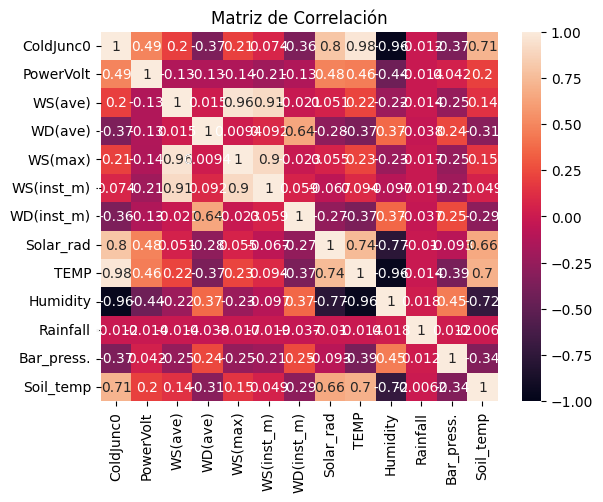

In [50]:
sns.heatmap(corr, annot=True, vmin=-1, vmax=1)
plt.title('Matriz de Correlación')
plt.show()

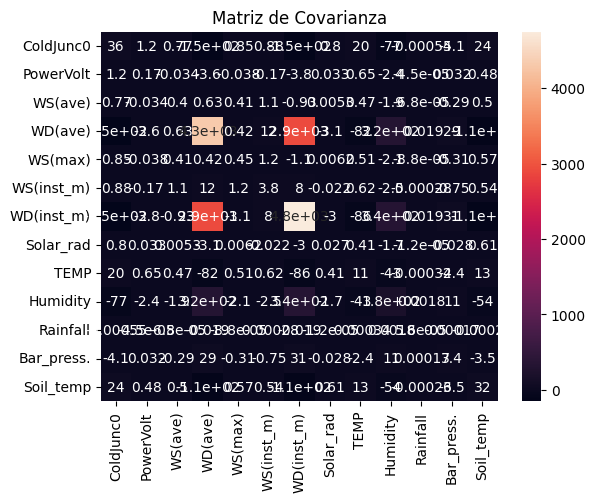

In [53]:
sns.heatmap(cov, annot=True)
plt.title('Matriz de Covarianza')
plt.show()

## Item 2

Identifique las variables más correlacionadas y grafíquelas unas vs. la otra en un gráfico de dispersión. Luego grafique cada una a lo largo del tiempo (para todas las fechas).

In [77]:
corr_unstack = corr.unstack()
corr_unstack = corr_unstack[corr_unstack < 1].abs()

corr_unstack.sort_values(ascending=False).head()

ColdJunc0  TEMP         0.976534
TEMP       ColdJunc0    0.976534
Humidity   ColdJunc0    0.961174
ColdJunc0  Humidity     0.961174
WS(ave)    WS(max)      0.959084
dtype: float64

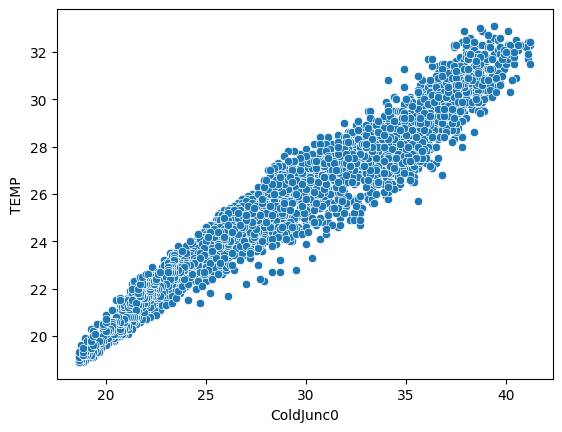

In [57]:
sns.scatterplot(x="ColdJunc0", y="TEMP", data=df)
plt.show()

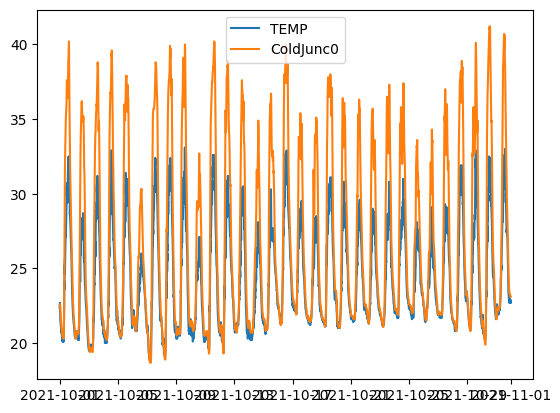

In [58]:
plt.plot(df["fecha"], df["TEMP"], label="TEMP")
plt.plot(df["fecha"], df["ColdJunc0"], label="ColdJunc0")

plt.legend()
plt.show()

Las variables más correlacionadas son `TEMP` y `ColdJunc0`, con un valor cercano a 0.98, lo que indica una relación lineal fuerte. El gráfico de dispersión muestra una clara tendencia, y en la evolución temporal ambas variables presentan comportamientos similares.

## Item 3

Identifique las variables menos correlacionadas y grafíquelas unas vs. la otra en un gráfico de dispersión. Luego grafique cada una a lo largo del tiempo (para todas las fechas).

In [78]:
corr_unstack.sort_values().head()

Soil_temp  Rainfall     0.006192
Rainfall   Soil_temp    0.006192
WS(max)    WD(ave)      0.009450
WD(ave)    WS(max)      0.009450
Rainfall   Solar_rad    0.009987
dtype: float64

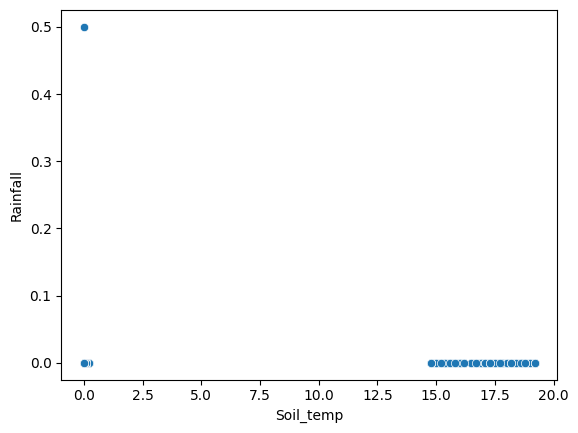

In [79]:
sns.scatterplot(x="Soil_temp", y="Rainfall", data=df)
plt.show()

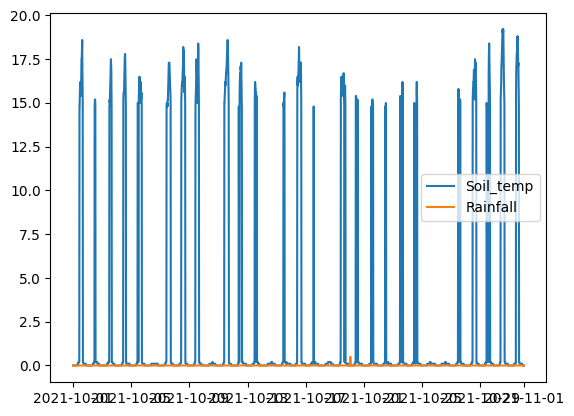

In [80]:
plt.plot(df["fecha"], df["Soil_temp"], label="Soil_temp")
plt.plot(df["fecha"], df["Rainfall"], label="Rainfall")

plt.legend()
plt.show()